# Bank Customer Churn Prediction & Retention Analytics System

## 02 — Data Cleaning & Exploratory Data Analysis

### Objective

This notebook performs data-quality validation, cleaning, exploratory data analysis, distribution analysis, relationship analysis, and outlier investigation.

The objective is to prepare a reliable analytical dataset while identifying relationships between customer characteristics and churn.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics


In [3]:
file_path = DATA_RAW / "bank_customer_churn.csv"

df = pd.read_csv(file_path)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 10,000 rows × 14 columns


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nExited:")
print(df["Exited"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Exited:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [8]:
binary_columns = [
    "HasCrCard",
    "IsActiveMember",
    "Exited"
]

for col in binary_columns:
    print(df[col].value_counts().sort_index())

HasCrCard
0    2945
1    7055
Name: count, dtype: int64
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64
Exited
0    7963
1    2037
Name: count, dtype: int64


In [9]:
print(
    "CreditScore range:",
    df["CreditScore"].min(),
    "to",
    df["CreditScore"].max()
)

CreditScore range: 350 to 850


In [10]:
print(
    "Age range:",
    df["Age"].min(),
    "to",
    df["Age"].max()
)

Age range: 18 to 92


In [11]:
print(
    "Tenure range:",
    df["Tenure"].min(),
    "to",
    df["Tenure"].max()
)

Tenure range: 0 to 10


In [12]:
print(
    "NumOfProducts range:",
    df["NumOfProducts"].min(),
    "to",
    df["NumOfProducts"].max()
)

NumOfProducts range: 1 to 4


In [13]:
df_clean = df.copy()

identifier_columns = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df_clean = df_clean.drop(columns=identifier_columns)

df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df_clean.shape

(10000, 11)

In [15]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

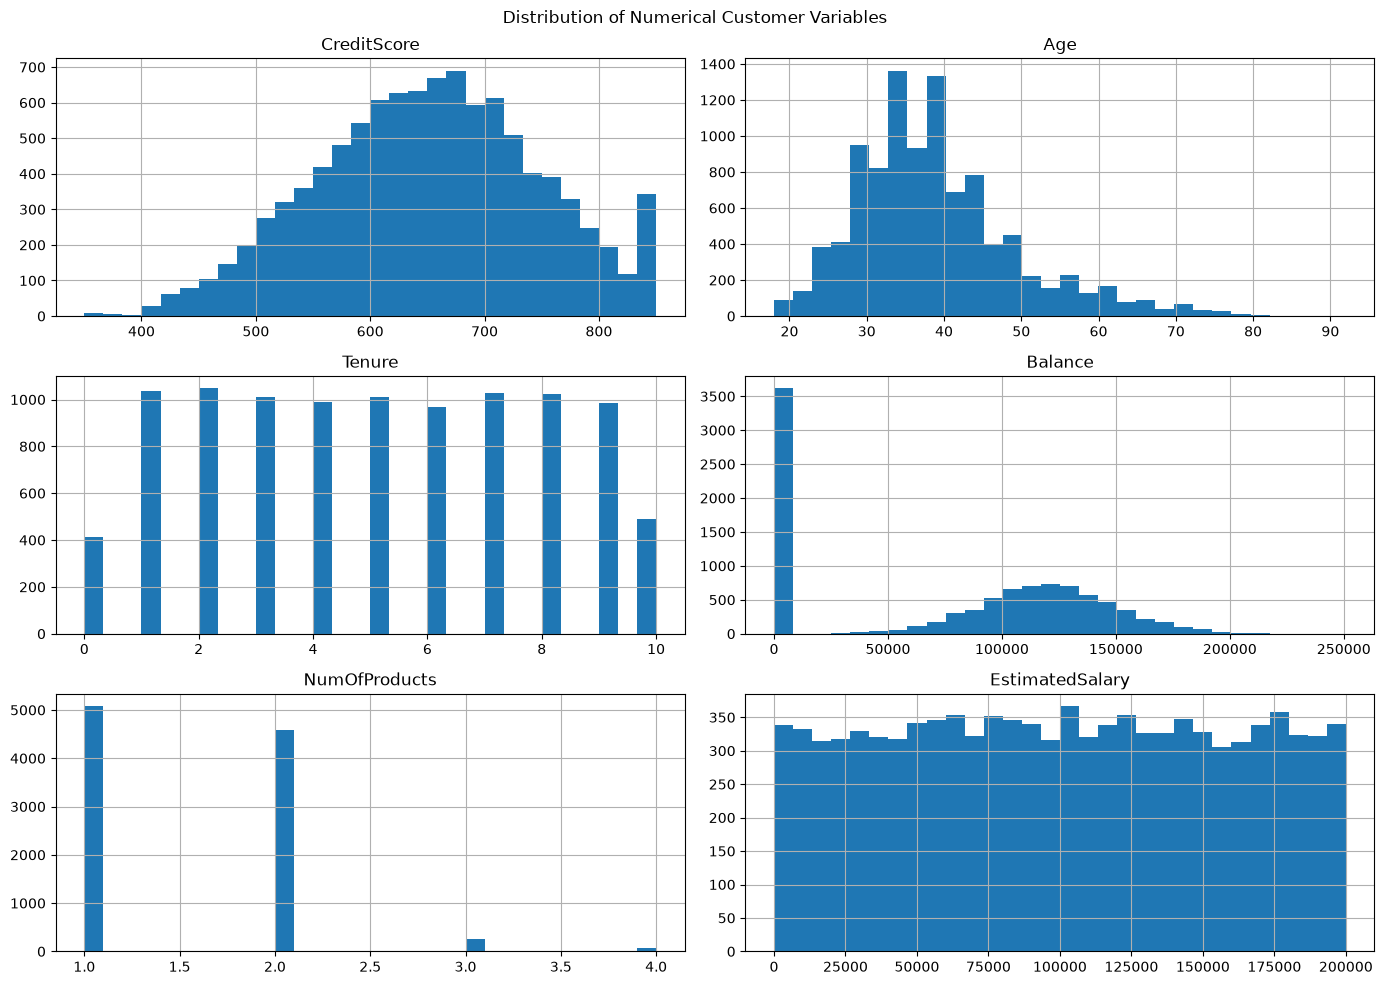

In [16]:
df_clean[numeric_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Customer Variables")

plt.tight_layout()
plt.show()

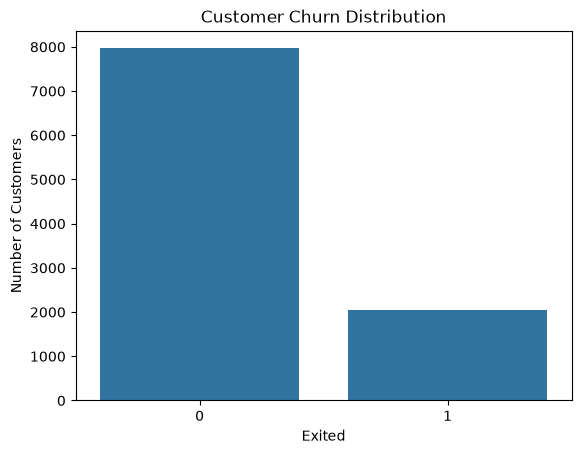

In [17]:
sns.countplot(
    data=df_clean,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

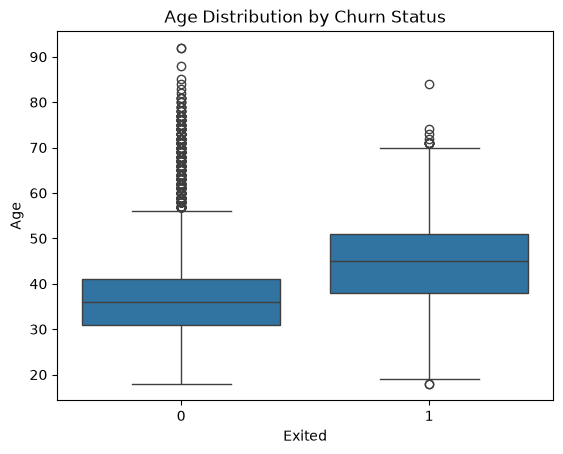

In [18]:
sns.boxplot(
    data=df_clean,
    x="Exited",
    y="Age"
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Age")

plt.show()

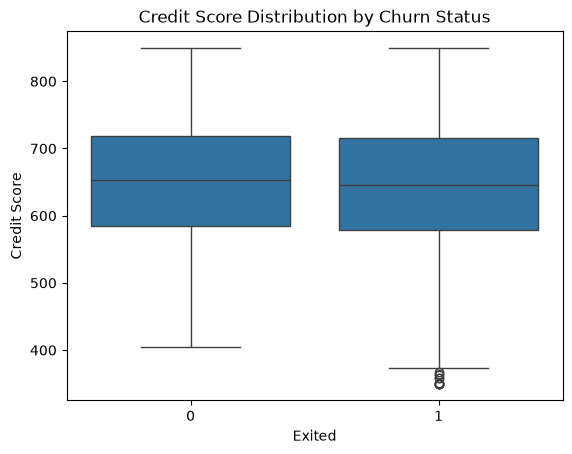

In [19]:
sns.boxplot(
    data=df_clean,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Credit Score")

plt.show()

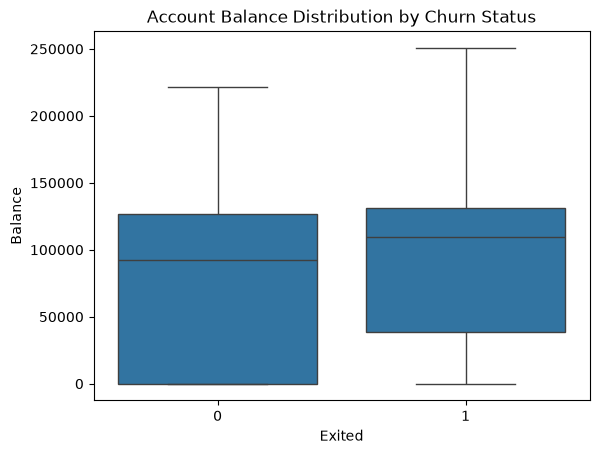

In [20]:
sns.boxplot(
    data=df_clean,
    x="Exited",
    y="Balance"
)

plt.title("Account Balance Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Balance")

plt.show()

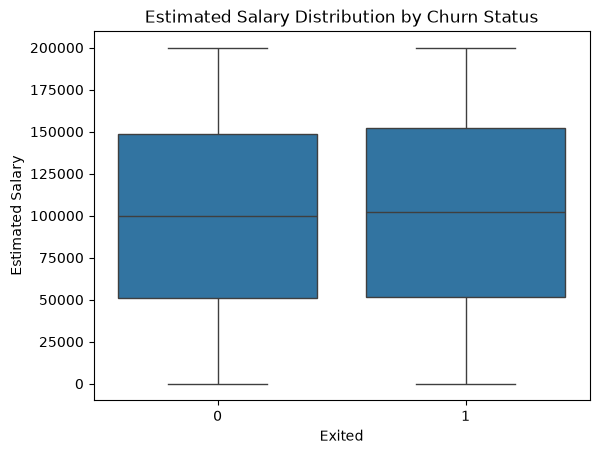

In [21]:
sns.boxplot(
    data=df_clean,
    x="Exited",
    y="EstimatedSalary"
)

plt.title("Estimated Salary Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Estimated Salary")

plt.show()

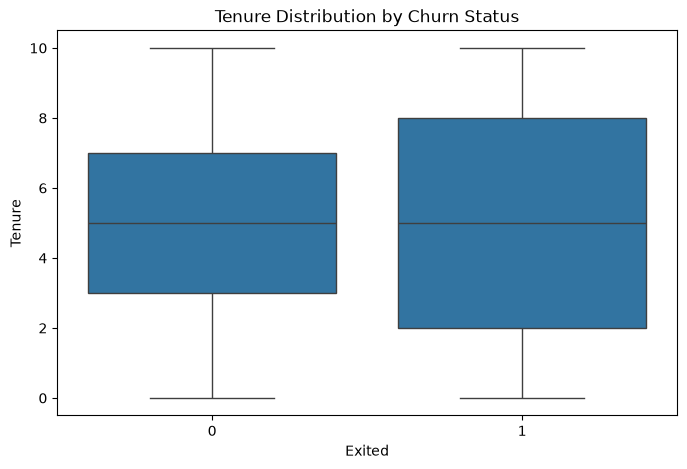

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Exited",
    y="Tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Tenure")

plt.show()

In [23]:
correlation = df_clean[numeric_columns + ["Exited"]].corr()

correlation

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204,-0.047820
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,0.012097,1.000000


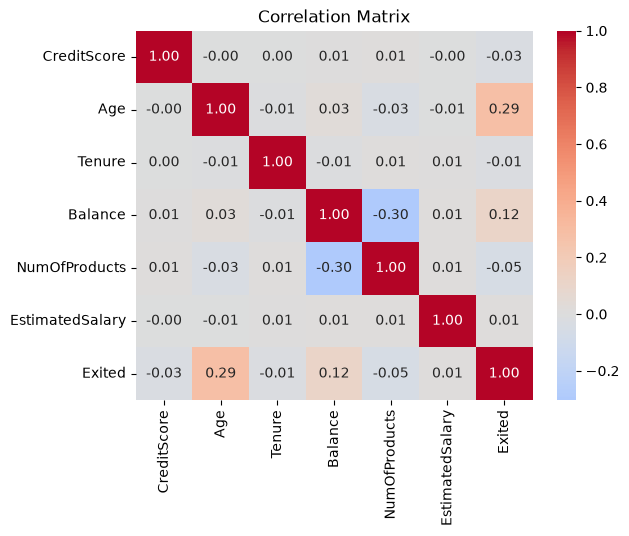

In [24]:
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
geo_analysis = pd.crosstab(
    df_clean["Geography"],
    df_clean["Exited"],
    normalize="index"
) * 100

geo_analysis.round(2)

Exited,0,1
Geography,,
France,83.85,16.15
Germany,67.56,32.44
Spain,83.33,16.67


In [26]:
gender_analysis = pd.crosstab(
    df_clean["Gender"],
    df_clean["Exited"],
    normalize="index"
) * 100

gender_analysis.round(2)

Exited,0,1
Gender,,
Female,74.93,25.07
Male,83.54,16.46


In [27]:
activity_analysis = pd.crosstab(
    df_clean["IsActiveMember"],
    df_clean["Exited"],
    normalize="index"
) * 100

activity_analysis.round(2)

Exited,0,1
IsActiveMember,,
0,73.15,26.85
1,85.73,14.27


In [28]:
product_analysis = pd.crosstab(
    df_clean["NumOfProducts"],
    df_clean["Exited"],
    normalize="index"
) * 100

product_analysis.round(2)

Exited,0,1
NumOfProducts,,
1,72.29,27.71
2,92.42,7.58
3,17.29,82.71
4,0.00,100.00


In [29]:
outlier_summary = []

for col in numeric_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers,
        "outlier_percentage": round(
            outliers / len(df_clean) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15,0.15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359,3.59
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0,0.00
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0,0.00
4,NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60,0.60
5,EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0,0.00


In [30]:
cleaned_path = DATA_PROCESSED / "bank_customer_churn_cleaned.csv"

df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_path)

Cleaned dataset saved to:
C:\Users\balle\customer-churn-prediction-retention-analytics\data\processed\bank_customer_churn_cleaned.csv


In [31]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 10000
Columns: 11
Missing values: 0
Duplicate rows: 0


## Key EDA Findings

### Numerical Distributions

- CreditScore shows an approximately bell-shaped distribution with very few statistical outliers.
- Age is right-skewed, with most customers concentrated in the 30–40 age range and fewer customers at older ages.
- Tenure is a discrete variable ranging from 0 to 10 years.
- Balance has a substantial concentration at zero, indicating that zero-balance customers represent an important segment rather than invalid observations.
- NumOfProducts is highly concentrated around one and two products, with relatively few customers having three or four products.
- EstimatedSalary shows a relatively broad and approximately uniform distribution with no IQR-based outliers.

### Correlation Findings

Age has the strongest linear correlation with churn among the numerical variables, with a correlation coefficient of approximately 0.285.

Balance has a weaker positive correlation with churn of approximately 0.119.

CreditScore, Tenure, NumOfProducts, and EstimatedSalary have relatively weak linear correlations with churn.

The weak correlation between NumOfProducts and churn should not be interpreted as evidence that product count is unimportant. The categorical churn analysis revealed a strongly non-linear relationship, with substantially different churn rates across product-count groups.

Balance and NumOfProducts show the strongest correlation among the predictor variables, at approximately -0.304.

### Outlier Findings

IQR-based analysis identified statistical outliers in CreditScore, Age, and NumOfProducts. These observations were retained because they represent valid values within the dataset.

In particular, customers above age 62 and customers with four products should not automatically be considered data-quality errors. Statistical outlier detection is being used for investigation rather than automatic removal.

### Key Analytical Principle

The EDA demonstrates that linear correlation alone is insufficient to capture all relationships with churn. Some variables may have non-linear or segment-specific relationships that should be evaluated using categorical analysis and machine learning models.

In [32]:
churn_numeric_summary = (
    df_clean
    .groupby("Exited")[numeric_columns]
    .agg(["mean", "median"])
    .round(2)
)

churn_numeric_summary

CreditScore           Age        Tenure          Balance             \
              mean median   mean median   mean median      mean     median   
Exited                                                                       
0           651.85  653.0  37.41   36.0   5.03    5.0  72745.30   92072.68   
1           645.35  646.0  44.84   45.0   4.93    5.0  91108.54  109349.29   

       NumOfProducts        EstimatedSalary             
                mean median            mean     median  
Exited                                                  
0               1.54    2.0        99738.39   99645.04  
1               1.48    1.0       101465.68  102460.84

In [33]:
churn_numeric_means = (
    df_clean
    .groupby("Exited")[numeric_columns]
    .mean()
    .T
)

churn_numeric_means.columns = ["Stayed", "Churned"]

churn_numeric_means["Difference"] = (
    churn_numeric_means["Churned"] -
    churn_numeric_means["Stayed"]
)

churn_numeric_means.round(2)

,Stayed,Churned,Difference
CreditScore,651.85,645.35,-6.50
Age,37.41,44.84,7.43
Tenure,5.03,4.93,-0.10
Balance,72745.30,91108.54,18363.24
NumOfProducts,1.54,1.48,-0.07
EstimatedSalary,99738.39,101465.68,1727.29


In [34]:
age_bins = [17, 25, 35, 45, 55, 65, 100]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

In [35]:
df["ActivityStatus"] = df["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

In [36]:
df[["Age", "AgeGroup", "IsActiveMember", "ActivityStatus"]].head()

,Age,AgeGroup,IsActiveMember,ActivityStatus
0,42,36-45,1,Active
1,41,36-45,1,Active
2,42,36-45,0,Inactive
3,39,36-45,0,Inactive
4,43,36-45,1,Active


In [37]:
age_activity = pd.crosstab(
    df["AgeGroup"],
    df["ActivityStatus"],
    values=df["Exited"],
    aggfunc="mean"
) * 100

age_activity.round(2)

ActivityStatus,Active,Inactive
AgeGroup,,
18-25,4.33,11.11
26-35,6.27,10.80
36-45,14.63,24.22
46-55,37.15,63.61
56-65,25.49,93.85
66+,6.47,62.50


In [38]:
geo_activity = pd.crosstab(
    df["Geography"],
    df["ActivityStatus"],
    values=df["Exited"],
    aggfunc="mean"
) * 100

geo_activity.round(2)

ActivityStatus,Active,Inactive
Geography,,
France,11.50,21.13
Germany,23.72,41.08
Spain,10.75,23.35


In [39]:
product_activity = pd.crosstab(
    df["NumOfProducts"],
    df["ActivityStatus"],
    values=df["Exited"],
    aggfunc="mean"
) * 100

product_activity.round(2)

ActivityStatus,Active,Inactive
NumOfProducts,,
1,18.92,36.65
2,5.56,9.89
3,75.22,88.24
4,100.00,100.00


In [40]:
age_geo = pd.crosstab(
    df["AgeGroup"],
    df["Geography"],
    values=df["Exited"],
    aggfunc="mean"
) * 100

age_geo.round(2)

Geography,France,Germany,Spain
AgeGroup,,,
18-25,5.23,11.19,8.64
26-35,5.79,14.80,8.54
36-45,16.04,31.36,14.83
46-55,44.39,67.00,41.16
56-65,44.80,64.86,36.96
66+,9.02,25.00,10.45


## Cross-Segment EDA Findings

Cross-segment analysis revealed that customer churn varies substantially across combinations of customer characteristics.

### Age and Activity

The combination of age and activity status shows a strong difference in observed churn. Older inactive customers exhibit particularly high churn rates, with the 56–65 inactive segment showing an observed churn rate of 93.85%.

This suggests that customer engagement may interact with age when identifying retention risk.

### Geography and Activity

Germany has higher churn rates than France and Spain among both active and inactive customers. Inactive customers in Germany show an observed churn rate of 41.08%.

This indicates that the elevated churn observed in Germany is not limited to inactive customers.

### Number of Products and Activity

The unusually high churn rates among customers with three and four products remain visible after separating customers by activity status. Customers with three products show churn rates of 75.22% among active customers and 88.24% among inactive customers, while all customers with four products in the dataset have exited.

Because these groups are relatively small, the findings should be treated as important patterns requiring further validation rather than broad causal conclusions.

### Age and Geography

Age-related churn differences remain visible across all three geographic groups. Customers aged 46–55 and 56–65 show particularly high churn, with Germany exhibiting the highest observed churn rates within these age groups.

### Overall Interpretation

The cross-segment analysis indicates that churn is influenced by combinations of customer characteristics rather than by isolated variables alone. These findings support the use of machine learning models capable of capturing nonlinear relationships and feature interactions.

In [41]:
df_clean.columns.tolist()

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [42]:
df_clean = df_clean.drop(
    columns=["AgeGroup", "ActivityStatus"],
    errors="ignore"
)

In [43]:
df_clean.shape

(10000, 11)

In [44]:
cleaned_path = DATA_PROCESSED / "bank_customer_churn_cleaned.csv"

df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Final cleaned analytical dataset saved.")

Final cleaned analytical dataset saved.


In [45]:
print("Shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

Shape: (10000, 11)
Missing values: 0
Duplicates: 0


# Day 2 — Final Conclusion

The customer dataset was successfully validated and prepared for further analysis.

No missing values or duplicate records were identified, and all major categorical and numerical variables were checked for consistency and plausible ranges.

The exploratory analysis identified several important patterns:

- Age is one of the strongest numerical indicators associated with churn.
- Churned customers are, on average, older and have higher account balances than retained customers.
- Tenure and estimated salary show relatively small differences between retained and churned customers.
- Credit card ownership shows limited standalone differentiation.
- Customer activity is strongly associated with churn, with inactive customers showing substantially higher churn rates.
- Germany consistently shows higher churn than France and Spain.
- Older customer segments, particularly ages 46–65, show substantially higher churn rates.
- The combination of age and inactivity produces particularly high observed churn rates.
- The unusual relationship between number of products and churn persists across activity groups, although the three- and four-product segments are relatively small.
- Correlation analysis demonstrates that linear relationships alone cannot capture all churn patterns, particularly the non-linear relationship associated with number of products.

Statistical outliers were investigated but not automatically removed because unusual values such as older customers or customers with four products can represent valid observations rather than data-quality errors.

The final analytical dataset contains 10,000 customers and 11 variables after excluding identifier fields that do not provide meaningful predictive information.

The dataset is now ready for the next stages of the project: deeper feature engineering, SQL-based customer analytics, and machine learning preparation.